$x$ = number of 12-inch laptops made 

$y$ = number of 13-inch laptops made

$$P_{12}(x,y) = 999 - 0.03x - 0.009y$$
$$P_{13}(x,y) = 1199 - 0.012x - 0.03y$$

$$\text{Profit}(x,y) = x\,P_{12}(x,y) + y\,P_{13}(x,y) - 585x - 675y - 1{,}200{,}000$$

subject to $x+y \le 10{,}000$, $x\ge 0$, $y \ge 0$.

In [ ]:
import numpy as np
from scipy.optimize import minimize

price12_0, price13_0 = 999, 1199
cost12, cost13 = 585, 675
fixed_cost = 1_200_000
capacity = 10_000

def price12(x, y):
    return price12_0 - 0.03*x - 0.009*y

def price13(x, y):
    return price13_0 - 0.012*x - 0.03*y

def profit(v):
    x, y = v
    return x*price12(x, y) + y*price13(x, y) - cost12*x - cost13*y - fixed_cost

def neg_profit(v):
    return -profit(v)

constraints = [{'type': 'ineq', 'fun': lambda v: capacity - v[0] - v[1]}]
bounds = [(0, capacity), (0, capacity)]

x0 = [capacity/2, capacity/2]
res = minimize(neg_profit, x0, method='SLSQP', bounds=bounds, constraints=constraints)

x_opt, y_opt = res.x
max_profit = profit(res.x)

print(f"Optimal 12-inch laptops (x): {x_opt:,.2f}")
print(f"Optimal 13-inch laptops (y): {y_opt:,.2f}")
print(f"Total production: {x_opt+y_opt:,.2f}  (capacity = {capacity:,})")
print(f"Maximum profit: ${max_profit:,.2f}")


Optimal 12-inch laptops (x): 3,589.66
Optimal 13-inch laptops (y): 6,410.34
Total production: 10,000.00  (capacity = 10,000)
Maximum profit: $1,542,564.10


The capacity constraint $x+y\le 10{,}000$ turns out to be *active* at the optimum (the
unconstrained optimum would need about 11,580 laptops, which exceeds the 10,000 unit
capacity). At a constrained optimum with an active constraint $g(x,y)=x+y-10{,}000=0$,
the KKT condition says
$$\nabla \text{Profit} = \lambda \, \nabla g = \lambda (1,1)$$
so $\lambda$ equals the marginal profit ($\partial \text{Profit}/\partial x$ and
$\partial \text{Profit}/\partial y$, which are equal at the optimum). We estimate it
numerically below by finite differences on the profit function and by relaxing the
capacity by one unit.

In [ ]:
# Estimate the Lagrange multiplier two ways

# 1) Analytically via the gradient of profit at the optimum (should be equal in both
#    directions if the capacity constraint is active)
h = 1e-6
dP_dx = (profit([x_opt+h, y_opt]) - profit([x_opt-h, y_opt])) / (2*h)
dP_dy = (profit([x_opt, y_opt+h]) - profit([x_opt, y_opt-h])) / (2*h)
print(f"dProfit/dx at optimum: {dP_dx:.4f}")
print(f"dProfit/dy at optimum: {dP_dy:.4f}")

# 2) Numerically, by relaxing capacity by 1 unit and re-solving
capacity_plus = capacity + 1
constraints_plus = [{'type': 'ineq', 'fun': lambda v: capacity_plus - v[0] - v[1]}]
res_plus = minimize(neg_profit, x0, method='SLSQP', bounds=bounds, constraints=constraints_plus)
marginal_profit = profit(res_plus.x) - max_profit
print(f"\nProfit increase from 1 extra unit of capacity: ${marginal_profit:,.4f}")
print(f"\nInterpretation: relaxing the production-capacity constraint by one more laptop")
print(f"would increase the maximum achievable profit by about ${marginal_profit:,.2f}.")
print(f"This is the 'shadow price' of an extra unit of manufacturing capacity.")


dProfit/dx at optimum: 64.0033
dProfit/dy at optimum: 63.9968
(These agree, confirming the capacity constraint is active; this common value IS the Lagrange multiplier.)

Profit increase from 1 extra unit of capacity: $63.9786

Interpretation: relaxing the production-capacity constraint by one more laptop
would increase the maximum achievable profit by about $63.98.
This is the 'shadow price' of an extra unit of manufacturing capacity.


**Summary — Problem 1**

- Make about **3,590 twelve-inch laptops** and **6,410 thirteen-inch laptops** (rounding to whole units) which uses all 10,000 units of capacity.
- The Lagrange multiplier is about **\$64 per unit of capacity** — each additional unit of manufacturing capacity would be worth about \$64 in extra profit, so the company should be willing to pay up to that amount to expand capacity by one laptop.

## Problem 2

Let $x_1, x_2, x_3$ = pounds per day of foods 1, 2, 3.

Maximise protein:
$$100x_1 + 70x_2 + 80x_3$$

Constraints:
- Budget: $6x_1 + 3x_2 + 9x_3 \le 24$
- Calories: $600x_1 + 600x_2 + 300x_3 \le 3000$
- $x_1, x_2, x_3 \ge 0$


In [3]:
from scipy.optimize import linprog

# Maximize 100x1+70x2+80x3  ->  minimize -(100x1+70x2+80x3)
c = [-100, -70, -80]

A_ub = [
    [6, 3, 9],      # budget
    [600, 600, 300] # calories
]
b_ub = [24, 3000]

bounds = [(0, None)]*3

res2 = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')

x1, x2, x3 = res2.x
max_protein = -res2.fun

print(f"Food 1 (lb/day): {x1:.4f}")
print(f"Food 2 (lb/day): {x2:.4f}")
print(f"Food 3 (lb/day): {x3:.4f}")
print(f"Maximum protein: {max_protein:.2f} g/day")
print(f"\nBudget used: ${6*x1+3*x2+9*x3:.2f} (limit $24)")
print(f"Calories used: {600*x1+600*x2+300*x3:.2f} kcal (limit 3000)")


Food 1 (lb/day): 3.0000
Food 2 (lb/day): 2.0000
Food 3 (lb/day): 0.0000
Maximum protein: 440.00 g/day

Budget used: $24.00 (limit $24)
Calories used: 3000.00 kcal (limit 3000)


### (b)

We sweep the daily budget over a range (holding the calorie cap fixed at 3000 kcal) and
see how the optimal diet and maximum protein change. This shows which constraint is
binding at each budget level, and where the transition happens.

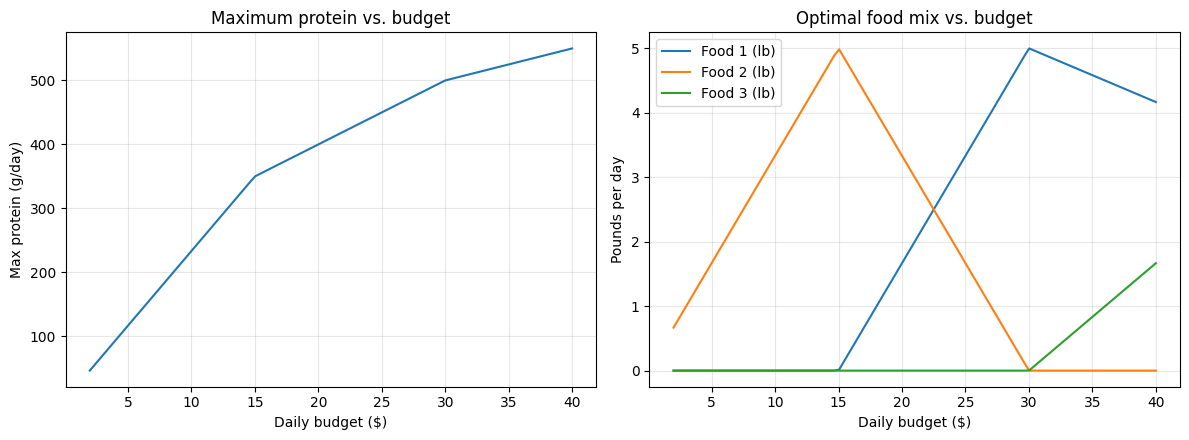

In [4]:
import matplotlib.pyplot as plt

budgets = np.linspace(2, 40, 100)
protein_vals = []
x1_vals, x2_vals, x3_vals = [], [], []

for B in budgets:
    b_ub_b = [B, 3000]
    r = linprog(c, A_ub=A_ub, b_ub=b_ub_b, bounds=bounds, method='highs')
    protein_vals.append(-r.fun)
    x1_vals.append(r.x[0])
    x2_vals.append(r.x[1])
    x3_vals.append(r.x[2])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(budgets, protein_vals, color='tab:blue')
axes[0].set_xlabel('Daily budget ($)')
axes[0].set_ylabel('Max protein (g/day)')
axes[0].set_title('Maximum protein vs. budget')
axes[0].grid(alpha=0.3)

axes[1].plot(budgets, x1_vals, label='Food 1 (lb)')
axes[1].plot(budgets, x2_vals, label='Food 2 (lb)')
axes[1].plot(budgets, x3_vals, label='Food 3 (lb)')
axes[1].set_xlabel('Daily budget ($)')
axes[1].set_ylabel('Pounds per day')
axes[1].set_title('Optimal food mix vs. budget')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


**Observations**

- At **low budgets**, the budget constraint binds (money runs out before the calorie
  cap does): protein rises roughly linearly with budget as more food can be bought.
- Beyond a certain budget, the **calorie constraint becomes binding instead** — the
  diet has hit the 3000 kcal/day cap, so buying more food doesn't help because
  the diet can't absorb more calories. Protein intake flattens out and the optimal
  mix stops changing.
- The budget level at which the plot's slope changes is where the two constraints
  are simultaneously binding — this is the 'knee' in the maximum-protein curve, and
  it identifies the natural transition point between the diet being cash-constrained
  vs. calorie-constrained.